In [288]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [289]:
from get_model_probabilities import *
import scienceplots
plt.style.use(["science","grid"])
from sidm_inference_on_data_and_models import infer_sidm
from scipy.stats import binned_statistic
from matplotlib import gridspec

# So the plan is to have a table of all summarised systematics.
-----

In [487]:
systematics = {
        'cluster_member_contamination': f"pickles/cluster_contamination_concat.pkl",
    'shape_measurement_bias':"pickles/shape_measurement_concat_test.pkl",
     'source_redshift_bias':"pickles/all_models_concat_nzbias_results.pkl",
    'projection_integration':"pickles/flamingo_dz_results.pkl",

}   
systematics_thresh= {
        'mass_dependency': "pickles/mass_data_zs_dependence.pkl",
    'merging_scenario':"pickles/component_results.pkl"
}


cluster_member_contamination
shape_measurement_bias
source_redshift_bias
projection_integration


Text(0.5, 0, 'Model Output')

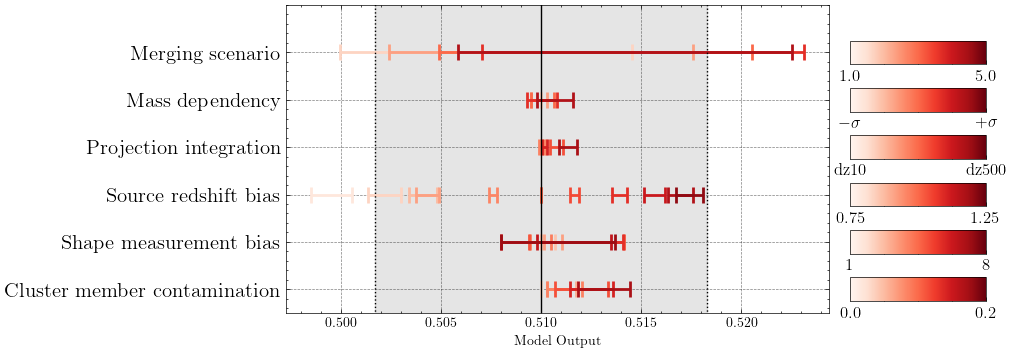

In [491]:
fig = plt.figure(figsize=(7,4))
ax = plt.gca()
corr = 2.8
systematic_names = []

capsize = 6



for isx, isystematic in enumerate(systematics.keys()):
    
    fiducial, all_results = pkl.load(open(systematics[isystematic],"rb"))
    
    print(isystematic)
    colors = colourFromRange([-1,len(all_results.keys())], cmap='Reds')
    ibias_keys = np.sort(list(all_results.keys()))

    norm = mpl.colors.Normalize(vmin=-1, vmax=len(all_results.keys()))
    cmap = plt.cm.Reds

    
    for ibx, ibias in enumerate(ibias_keys):
        all_thresholds = []
        color = cmap(norm(ibx))
        for imodel in all_results[ibias].keys():
            if 'seed' not in imodel:
                continue
                
            if isinstance(all_results[ibias][imodel],dict):

                    
                tgt = get_threshold_for_cross( 
                    all_results[ibias][imodel]['src'], 
                    quiet=False)
                
                fid = get_threshold_for_cross( 
                    fiducial[imodel]['src'], 
                    quiet=False)
            elif isinstance(all_results[ibias][imodel],list):
                
                tgt = get_threshold_for_cross( 
                    all_results[ibias][imodel], 
                    quiet=False)
                fid = get_threshold_for_cross( 
                    fiducial[imodel], 
                    quiet=False)
                
            all_thresholds.append((1-tgt['thresholds'])/(1-fid['thresholds']))
            
        all_thresholds = np.array(all_thresholds)
        
        means = np.nanmean(all_thresholds,axis=0)* central_value
        errors = np.std(all_thresholds,axis=0) / np.sqrt(all_thresholds.shape[0]) 
        
        ax.errorbar(  means[ tgt['cross_sections'] == 0], isx, xerr=errors[ tgt['cross_sections'] == 0], 
                    capsize=capsize, color=colors[ibx], lw=2, capthick=2)
    
    cax = inset_axes(
        ax,
        width="25%",      # width of colorbar
        height="50%",      # thickness
        loc="center right",
        bbox_to_anchor=(0.29, isx-0.5, 1, 1),
        bbox_transform=ax.get_yaxis_transform(),
        borderpad=0,
    )

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = plt.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_ticks([-1,len(ibias_keys)])
    if isystematic =='shape_measurement_bias':
        ibias_keys = ibias_keys.astype(float)
        ibias_keys[0] = 0.02
        ibias_keys[-1] = 0.00
    cbar.set_ticklabels([ibias_keys[0], ibias_keys[-1]])
    cbar.ax.tick_params(labelsize=12)
    
    
    systematic_names.append(isystematic.replace('_',' ').capitalize())

for isy, isystematic in enumerate(systematics_thresh.keys()):
    
    fiducial, results = pkl.load(open(systematics_thresh[isystematic],"rb"))
    
    colors = colourFromRange([-1,len(results.keys())], cmap='Reds')
  
    ibias_keys = np.sort(list(results.keys()))
    colors = colourFromRange([-1,len(ibias_keys)], cmap='Reds')
    

    norm = mpl.colors.Normalize(vmin=-1, vmax=len(ibias_keys))
    cmap = plt.cm.Reds  
    for ibx, ibias in enumerate(ibias_keys):
        
        if 'thresholds' in list(results[ibias]['bahamas'].keys()):
            all_thresholds = (1-results[ibias]['bahamas']['thresholds'])/(1-fiducial['bahamas']['thresholds']) 
            cross_sections =  results[ibias]['bahamas']['cross_section']


            means = np.mean(all_thresholds,axis=0)* central_value

            errors = np.std(all_thresholds,axis=0)/np.sqrt(all_thresholds.shape[0])

        else:
            means = (1-results[ibias]['bahamas']['mean'])/(1-fiducial['bahamas']['mean']) * central_value
            errors = results[ibias]['bahamas']['err']/fiducial['bahamas']['mean'] * central_value
    
            
        ax.errorbar(  means[cross_sections==0], isy+isx+1, 
                    xerr = errors[cross_sections==0], 
                    capsize=capsize, color=colors[ibx], lw=2, capthick=2)
    
    cax = inset_axes(
        ax,
        width="25%",      # width of colorbar
        height="50%",      # thickness
        loc="center right",
        bbox_to_anchor=(0.29, isy+isx-0.5+1, 1, 1),
        bbox_transform=ax.get_yaxis_transform(),
        borderpad=0,
    ) 
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = plt.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_ticks([-1,len(ibias_keys)])
    if isystematic =='merging_scenario':
        ibias_keys = ibias_keys.astype(float)
        ibias_keys += 1

    if isystematic == 'mass_dependency':
        ibias_keys = ibias_keys.astype(str)
        ibias_keys[0] = r"$-\sigma$"
        ibias_keys[-1] = r"$+\sigma$"
    

    cbar.set_ticklabels([ibias_keys[0], ibias_keys[-1]])
    cbar.ax.tick_params(labelsize=12)
    
    
    systematic_names.append(isystematic.replace('_',' ').capitalize())
ax.set_yticks(np.arange(len(systematic_names)))
ax.set_yticklabels(systematic_names, fontsize=15)   


model, obs_results, nois = pkl.load(open( "pickles/model_on_data.pkl","rb"))
        
obs_results = 1-np.mean(probs['concat'])
obs_err = np.std(probs['concat'])/probs['concat'].shape[0]**0.38*corr
#ax.errorbar( [obs_results, obs_results],  [-1,len(systematic_names)+1], color='k')
#ax.fill_between( 
#    [obs_results-obs_err, obs_results+obs_err],
#    [-1,-1], [len(systematic_names)+1]*2, color='k', alpha=0.2
#)
#ax.plot( [obs_results-obs_err, obs_results-obs_err],  [-1,len(systematic_names)+1], ':', color='k')
#ax.plot( [obs_results+obs_err, obs_results+obs_err],  [-1,len(systematic_names)+1],  ':',color='k')

#ax.text( obs_results, len(systematic_names)/2., "Observation", ha='right', va='top', rotation=90, fontsize=15)

central_value = 0.51
central_error = 0.0083

ax.plot( [central_value, central_value],  [-1,len(systematic_names)+1], color='k')
ax.plot( [central_value+central_error, central_value+central_error],  [-1,len(systematic_names)+1], ':', color='k')
ax.plot( [central_value-central_error, central_value-central_error],  [-1,len(systematic_names)+1],  ':',color='k')

ax.fill_between( 
    [central_value-central_error, central_value+central_error],
    [-1,-1], [len(systematic_names)+1]*2, color='k', alpha=0.1
)


ax.set_ylim(-0.5,len(systematic_names))
ax.set_xlabel("Model Output")

[]


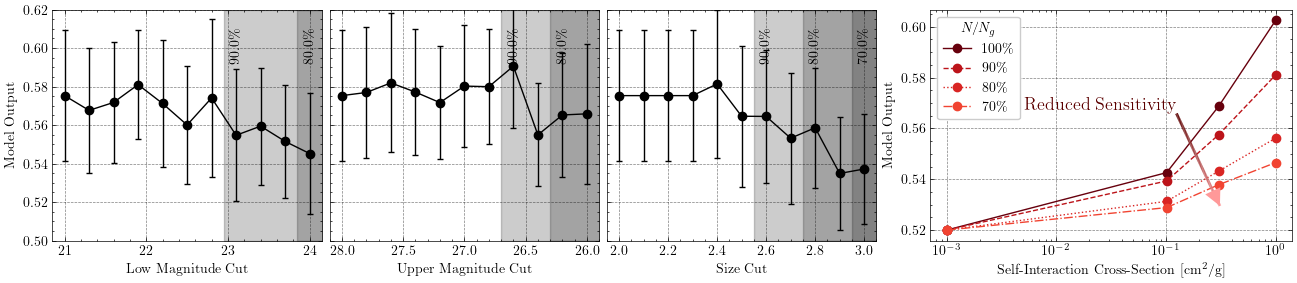

In [403]:

alpha=0.2
ylim = (0.5,0.62)
models, probabilities, probabilities_noise, ngalaxies = pkl.load( open("pickles/model_on_data_galaxy_selection.pkl","rb"))

ifilter = 'concat'
all_mag_low_cuts = np.linspace(21,24,11)
all_mag_cuts = np.linspace(28,26,11)
all_siz_cuts = np.linspace(2,3,11)

ngalaxies = ngalaxies/ngalaxies[0]
#fig,ax = plt.subplots(1,4,figsize=(16,3))
figure = plt.figure(figsize=(16,3))
gs = gridspec.GridSpec(1,27)

ax = [
    plt.subplot(gs[0,:6]),
    plt.subplot(gs[0,6:12]),
    plt.subplot(gs[0,12:18]),
    plt.subplot(gs[0,19:])]


ifilter='concat'
fig.subplots_adjust(wspace=0.1)
start_index = 0
end_index = all_mag_low_cuts.shape[0]
means =  np.mean(probabilities_noise[ifilter][:,start_index:end_index],axis=0) 
errors =  np.std(probabilities_noise[ifilter][:,start_index:end_index],axis=0) 
ngal = ngalaxies[start_index:end_index]

fiducial = 1-np.mean(probabilities_noise[ifilter][:,0],axis=0) 


ax[0].errorbar( all_mag_low_cuts, (1-means), errors, capsize=2, fmt='o-', color='k')
ax[0].set_xlabel("Low Magnitude Cut")  
ax[0].set_ylim(ylim)
ax[0].set_ylabel("Model Output")
print(all_mag_low_cuts[ ngal < limit])
for limit in [0.9,0.8,0.7]:
    if np.sum( ngal < limit) == 0:
        continue
        
    dx = (all_mag_low_cuts[1] - all_mag_low_cuts[0])/2.
    x = np.linspace( 
        all_mag_low_cuts[ ngal < limit][0]-dx,
        all_mag_low_cuts[ ngal < limit][-1]+dx*3,
        100
    )
    y_low = np.zeros( x.shape[0])+ax[0].get_ylim()[0]
    y_hi = np.zeros( x.shape[0])+ax[0].get_ylim()[1]

    
    ax[0].fill_between( 
        x, y_low, y_hi, color='k', alpha=alpha
    )
    ax[0].text(
        all_mag_low_cuts[ ngal < limit][0]-dx/2., 0.61, f"{limit*100}\%", va='top', ha='left', rotation=90)
    
    ax[0].set_xlim(
        all_mag_low_cuts[0]-dx,
        all_mag_low_cuts[-1] +dx
    )
    
start_index += all_mag_low_cuts.shape[0]
end_index += all_mag_cuts.shape[0]
means =  np.mean(probabilities_noise[ifilter][:,start_index:end_index],axis=0) 
errors =  np.std(probabilities_noise[ifilter][:,start_index:end_index],axis=0) 
ngal = ngalaxies[start_index:end_index]

ax[1].errorbar( all_mag_cuts, (1-means), errors, capsize=2, fmt='o-', color='k')
ax[1].set_xlabel("Upper Magnitude Cut")  
ax[1].set_ylim(ylim)
ax[1].set_yticklabels([])
for limit in [0.9,0.8,0.7]:
    if np.sum( ngal < limit) == 0:
        continue
        
    dx = (all_mag_cuts[1] - all_mag_cuts[0])/2.
    x = np.linspace( 
        all_mag_cuts[ ngal < limit][0]-dx,
        all_mag_cuts[ ngal < limit][-1]+dx*3,
        100
    )
    y_low = np.zeros( x.shape[0])+ax[0].get_ylim()[0]
    y_hi = np.zeros( x.shape[0])+ax[0].get_ylim()[1]

    
    ax[1].fill_between( 
        x, y_low, y_hi, color='k', alpha=alpha
    )
    ax[1].text(
        all_mag_cuts[ ngal < limit][0]-dx/2., 0.61, f"{limit*100}\%", va='top', ha='left', rotation=90)
    
    ax[1].set_xlim(
        all_mag_cuts[0]-dx,
        all_mag_cuts[-1] +dx
    )
start_index += all_mag_cuts.shape[0]
end_index += all_siz_cuts.shape[0]
means =  np.mean(probabilities_noise[ifilter][:,start_index:end_index],axis=0) 
errors =  np.std(probabilities_noise[ifilter][:,start_index:end_index],axis=0) 
ngal = ngalaxies[start_index:end_index]

ax[2].errorbar( all_siz_cuts, (1-means), errors, capsize=2, fmt='o-', color='k')
ax[2].set_ylim(ylim)

ax[2].set_xlabel("Size Cut")
ax[2].set_yticklabels([])
for limit in [0.9,0.8,0.7]:
    if np.sum( ngal < limit) == 0:
        continue
        
    dx = (all_siz_cuts[1] - all_siz_cuts[0])/2.
    x = np.linspace( 
        all_siz_cuts[ ngal < limit][0]-dx,
        all_siz_cuts[ ngal < limit][-1]+dx*3,
        100
    )
    y_low = np.zeros( x.shape[0])+ax[0].get_ylim()[0]
    y_hi = np.zeros( x.shape[0])+ax[0].get_ylim()[1]

    
    ax[2].fill_between( 
        x, y_low, y_hi, color='k', alpha=alpha
    )
    ax[2].text(
        all_siz_cuts[ ngal < limit][0]-dx/2., 0.61, f"{limit*100}\%", va='top', ha='left', rotation=90)
    
    ax[2].set_xlim(
        all_siz_cuts[0]-dx,
        all_siz_cuts[-1] +dx
    )
    
srcresults,tgtresults = pkl.load(open("pickles/all_models_concat_ngal_dep_results.pkl","rb"))

color = {
        'src':colourFromRange([0,len(tgtresults.keys())], cmap='Reds'),
        'tgt':colourFromRange([0,len(tgtresults.keys())], cmap='Blues')
    }

only_one = False
ils=0
ls = ['-','--',':','-.']
ngalaxy_list = list(tgtresults.keys())[::-1]
for irx, iresult in enumerate(ngalaxy_list):
    if float(iresult) < 0.6:
        continue
    
    if f"{float(iresult):0.1f}" == '1.0':
        if only_one:
            continue
        only_one=True
    ax[-1].plot(
        srcresults[iresult][0]+1e-3,
        (srcresults[iresult][1]-srcresults[iresult][1][0])*2.5+ 0.52,
        'o',ls=ls[ils],label=f"{int(np.round(float(iresult),1)*100)}\%", color=color['src'][len(ngalaxy_list) -irx])
    ils+=1
ax[-1].set_xlabel("Self-Interaction Cross-Section [cm$^2$/g]")
ax[-1].set_ylabel("Model Output")
ax[-1].set_xscale('log')
ax[-1].legend(title='$N/N_{g}$',loc=2)




# --- gradient-colored 45-degree arrow (dark red -> light red) ---
# Define start (tail/text side) and end (tip/arrowhead) in axes fraction coords.
x0, y0 = 0.68, 0.55   # tail
x1, y1 = 0.8, 0.15   # tip (where the arrow points)

# Build a custom dark-red -> light-red colormap
gradient_cmap = mcolors.LinearSegmentedColormap.from_list(
    "darkred_lightred", ["#5c0000", "#ff9999"]
)

n_seg = 100
xs = np.linspace(x0, x1, n_seg)
ys = np.linspace(y0, y1, n_seg)
points = np.array([xs, ys]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

lc = LineCollection(
    segments,
    cmap=gradient_cmap,
    norm=plt.Normalize(0, 1),
    linewidth=2,
    transform=ax[-1].transAxes,
    zorder=10,
)
lc.set_array(np.linspace(0, 1, n_seg))
ax[-1].add_collection(lc)

# Arrowhead at the tip, colored with the "light" end of the gradient
arrow_head = FancyArrowPatch(
    (xs[-2], ys[-2]), (xs[-1], ys[-1]),
    transform=ax[-1].transAxes,
    arrowstyle='-|>',
    mutation_scale=30,
    color=gradient_cmap(1.0),
    linewidth=0,
    zorder=11,
)
ax[-1].add_patch(arrow_head)

# Text label at the tail end
ax[-1].text(
    x0, y0, "Reduced Sensitivity",
    transform=ax[-1].transAxes,
    fontsize=13, ha='right', va='bottom', color="#5c0000",
)



fig.align_ylabels()